In [ ]:

import numpy as np 
import pandas as pd 
import random 
import seaborn as sns 
import matplotlib.pyplot as plt 
from typing import Any 

In [2]:
# КОНСТАНТЫ 
NB_ROWS, NB_PLACES = 33, ['A', 'B', 'C', 'D', 'E', 'F']
FW_ROWS, FW_PLACES = 11, ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
BO_ROWS, BO_PLACES = 47, ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [ ]:
# ПУНКТ 1: ПОСТРОЕНИЕ МАТЕМАТИЧЕСКОЙ МОДЕЛИ ДЛЯ РАСЧЕТА ВРЕМЕНИ ПОСАДКИ И ВЫСАДКИ
# 1.1. СОЗДАНИЕ ПАССАЖИРОВ С ХАРАКТЕРИСТИКАМИ

def passengers_data_creator(
        row_number: int, 
        places_in_row: list[str], 
        bag_probability: float = 0.7,
        following_rules_probability: float = 0.8,
        load_factor: float = 1
        ) -> pd.DataFrame:
    '''
    создает pd.DataFrame с пассажирами, генерируя случайные характеристики 
    '''

    passengers_info = []  # информация о каждом созданном пассажире

    # генерация характеристик для каждого пассажира
    for row in range(1, row_number + 1):
        for place in places_in_row:
            # багаж
            has_bag = random.random() < bag_probability  # число меньше 0.7 -> пассажир с ручной кладью; иначе -> нет 

            # следование правилам 
            follows_rules = random.random() < following_rules_probability # число меньше 0.8 -> пассажир следует правилам; иначе -> нет 

            # скорость движения пассажира (м/сек)
            passenger_speed = round(max(0.3, np.random.normal(1.2, 0.3)), 1)

            # время укладки багажа (сек)
            if has_bag:
                baggage_stowage_time = round(max(0.3, np.random.normal(15, 5)), 1)
            else:
                baggage_stowage_time = 0  # если у пассажира нет багажа -> ноль (нечего класть)

            # информация о пассажире
            pass_info = (len(passengers_info) + 1, row, place, has_bag, follows_rules, passenger_speed, baggage_stowage_time)
            passengers_info.append(pass_info)

    COL_NAMES = ['passenger_id', 'row', 'seat', 'has_bag', 'follows_rules', 'passenger_speed', 'baggage_stowage_time']
    PASSENGERS_INFO_TABLE = pd.DataFrame(passengers_info, columns=COL_NAMES)

    if load_factor != 1:
        PASSENGERS_INFO_TABLE = PASSENGERS_INFO_TABLE.sample(frac=load_factor)

    return PASSENGERS_INFO_TABLE

passengers_data_creator(NB_ROWS, NB_PLACES)

,passenger_id,row,seat,has_bag,follows_rules,passenger_speed,baggage_stowage_time
0,1,1,A,False,False,0.6,0.0
1,2,1,B,True,True,1.0,14.8
2,3,1,C,True,True,1.3,13.7
3,4,1,D,False,True,1.3,0.0
4,5,1,E,True,True,1.7,12.6
...,...,...,...,...,...,...,...
193,194,33,B,True,False,1.0,22.7
194,195,33,C,True,True,1.1,19.0
195,196,33,D,True,True,1.1,19.6
196,197,33,E,False,False,1.2,0.0


In [ ]:
# ПУНКТ 1: ПОСТРОЕНИЕ МАТЕМАТИЧЕСКОЙ МОДЕЛИ ДЛЯ РАСЧЕТА ВРЕМЕНИ ПОСАДКИ И ВЫСАДКИ
# 1.2. ФУНКЦИЯ СОЗДАНИЯ ОЧЕРЕДИ НА ПОСАДКУ 

class BoardingQueueError(Exception):
    pass

def boarding_queue_creation(df: pd.DataFrame, boarding_method: str) -> pd.DataFrame:
    ALLOWED_BOARDING_METHODS = [
        'random',  # случайный порядок 
        'back_to_front',  # сортировка по номеру ряда от большего к меньшему
        'windows_first'  # сортировка по типу места: A & F (окна) -> B & E (середина) -> C & D (проход)
        ]
    
    def window_first_sorter(seats: pd.Series) -> pd.Series:
        sorted_seats = sorted(seats, key=lambda s: 1 if s in 'AF' else 2 if s in 'BE' else 3)
        return pd.Series(sorted_seats)

    boarding_method = boarding_method.strip().lower()

    if boarding_method not in ALLOWED_BOARDING_METHODS:
        raise BoardingQueueError('Boarding method not found. Try again.')

    if boarding_method == 'random':
        result = pd.DataFrame.sample(df, frac=1).reset_index(drop=True)
        return result 
    
    if boarding_method == 'back_to_front':
        result = df.sort_values(by='row', ascending=False).reset_index(drop=True)
        return result 
    
    if boarding_method == 'windows_first': 
        result = df.sort_values(by='seat', key=window_first_sorter).reset_index(drop=True)
        return result 

In [ ]:
# ПУНКТ 1: ПОСТРОЕНИЕ МАТЕМАТИЧЕСКОЙ МОДЕЛИ ДЛЯ РАСЧЕТА ВРЕМЕНИ ПОСАДКИ И ВЫСАДКИ
# 1.3. СИМУЛЯЦИЯ ПОСАДКИ 

def create_empty_plane() -> tuple[list, list]:
    '''
    создаёт две структуры, описывающие пустой самолёт
    '''

    PLACES_MATRIX = [['free'] * len(NB_PLACES) for _ in range(NB_ROWS)]  # матрица мест: список из 33 элементов, каждый элемент - список из 6 строк 'free'
    PASSAGE_MATRIX = ['free' for _ in range(NB_ROWS)]  # 33 ряда (прохода), изначально все свободны 

    return PLACES_MATRIX, PASSAGE_MATRIX


def initialize_simulation(passengers_queue: pd.DataFrame) -> dict[str, Any]:
    '''
    принимает очередь пассажиров и создаёт начальное состояние всей симуляции
    '''

    seat_matrix, aisle_matrix = create_empty_plane()

    state = {
        'time': 0.0,  # число, текущее время симуляции
        'queue': passengers_queue,  # пассажиры, к-е ещё не зашли в самолёт
        'next_queue_index': 0,  # индекс следующего пассажира в списке queue
        'active_passengers': [],  # пустой список пассажиров, к-е уже в самолёте
        'seat_matrix': seat_matrix,  # матрица мест
        'aisle_matrix': aisle_matrix,  # матрица прохода
        'total_passengers': len(passengers_queue),  # общее число пассажиров - длина списка queue
        'boarded_ids': [],  # список id пассажиров, зашедших в самолет 
        'finished': 'no'  # флаг завершения симуляции 
    }  # словарь с информацией о симуляции 

    return state 


def update_boarding(state: dict[str, Any], time_step: float) -> dict[str, Any]:
    '''
    принимает текущее состояние state и шаг времени time_step (например, 0.1). делает один шаг симуляции и возвращает обновлённое состояние
    '''

    # ЭТАП 1: ЗАПУСК НОВЫХ ПАССАЖИРОВ ИЗ ОЧЕРЕДИ
    while state['aisle_matrix'][0] == 'free' and (state['next_queue_index']) < state['total_passengers']:  # пока свободен проход в первом ряду (вход в самолет) и есть пассажиры в очереди, к-е еще не зашли
        
        df_cur_pass = None 
        index_increase_flag = True

        # логика проверки для тех, кто не следует правилам 
        for _, p in state['queue'].iterrows():
            if not p.follows_rules:
                if not p.passenger_id in state['boarded_ids']:
                    df_cur_pass = p
                    index_increase_flag = False
                    break 

        if df_cur_pass is None:
            df_cur_pass = state['queue'].iloc[state['next_queue_index']]
        
        active_passenger_record = {
            'id': df_cur_pass.passenger_id,
            'target_row': df_cur_pass.row,
            'target_seat': df_cur_pass.seat,
            'current_row': 1,  # текущий ряд для пассажира (только что зашел в самолет)
            'progress_in_row': 0,  # сколько метров прошел внутри текущего ряда
            'state': 'walking',  # что делает (состояние пассажира)
            'timer': 0,  # таймер для действий 
            'speed': df_cur_pass.passenger_speed,  # скорость пассажира 
            'has_bag': df_cur_pass.has_bag,  # информация о наличии багажа 
            'bag_time': df_cur_pass.baggage_stowage_time  # время укладки вещей 
        }  # запись об одном пассажире 

        state['active_passengers'].append(active_passenger_record)  # добавление созданного словаря в список активных пассажиров (те, кто в самолете)
        state['boarded_ids'].append(df_cur_pass.passenger_id)

        state['aisle_matrix'][0] = 'blocked'  # вход занят вошедшим пассажиром 
        if index_increase_flag:
            state['next_queue_index'] += 1  # увеличение счетчика след. пассажира 

    
    # ЭТАП 2: ОБРАБОТКА ВСЕХ АКТИВНЫХ ПАССАЖИРОВ
    for p in state['active_passengers']:  # проход по каждому словарю в списке пассажиров в самолете
        
        if p['state'] == 'walking':
            if p['target_row'] == p['current_row']:  # если пассажир уже дошел до своего ряда 
                p['state'] = 'thinking_about_bag'
                p['progress_in_row'] = 0
            else:
                if state['aisle_matrix'][p['current_row']] == 'free':  # если след. ряд свободен
                    p['progress_in_row'] += p['speed'] * time_step  
                    if p['progress_in_row'] >= 1:  # если пассажир прошел 1 ряд (1 метр)
                        old_index = p['current_row'] - 1
                        state['aisle_matrix'][old_index] = 'free'
                        p['current_row'] += 1
                        p['progress_in_row'] -= 1
                        state['aisle_matrix'][p['current_row'] - 1] = 'blocked'

        elif p['state'] == 'thinking_about_bag':
            if p['has_bag'] and p['timer'] == 0:
                p['timer'] = p['bag_time']  
            elif p['has_bag'] and p['timer'] > 0:
                p['timer'] -= time_step
            else:
                p['state'] = 'trying_to_sit' 

        elif p['state'] == 'trying_to_sit':
            base_time = 2  # базовое время на посадку (если путь свободен)
            added_time = 0  # дополнительное время (если места заняты); за каждое занятое место +2 сек
            if p['target_seat'] in 'CD':  # если место в проходе (т.е. путь до него всегда свободен)
                p['timer'] = base_time  # 2 сек, чтобы сесть 
            elif p['target_seat'] in 'BE':  
                seat_index = 2 if p['target_seat'] == 'B' else 3  
                if state['seat_matrix'][p['target_row'] - 1][seat_index] == 'occupied':
                    added_time += 2
                p['timer'] = base_time + added_time
            elif p['target_seat'] in 'AF':
                seat_indexes = [1, 2] if p['target_seat'] == 'A' else [3, 4]  # если A, проверять индексы 1 и 2 (места B и C). если F, проверять 3 и 4 (места D и E).
                state_1, state_2 = state['seat_matrix'][p['target_row'] - 1][seat_indexes[0]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[1]]
                if state_1 == 'occupied':
                    added_time += 2
                if state_2 == 'occupied':
                    added_time += 2
                p['timer'] = base_time + added_time
            p['state'] = 'sitting_down'  # пассажир заходит в ряд → проход освобождается
            state['aisle_matrix'][p['current_row'] - 1] = 'free' 
                    

        elif p['state'] == 'sitting_down':
            p['timer'] -= time_step  
            if p['timer'] <= 0:  # если пассажир сел 
                target_seat_index = NB_PLACES.index(p['target_seat'])
                state['seat_matrix'][p['target_row'] - 1][target_seat_index] = 'occupied'  # место занято 
                p['to_remove'] = True  # пассажира нужно удалить из списка тех, кто зашел, т.к. он уже сел

    state['active_passengers'] = [p for p in state['active_passengers'] if not p.get('to_remove')]


    # ЭТАП 3: ПРОВЕРКА ЗАВЕРШЕНИЯ 
    if state['next_queue_index'] == state['total_passengers'] and not state['active_passengers']:  # если все пассажиры из очереди зашли и список активных пассажиров пуст 
        state['finished'] = 'yes'  # завершено

    
    # ЭТАП 4: УВЕЛИЧЕНИЕ ВРЕМЕНИ И ВОЗВРАТ 
    state['time'] += time_step if state['finished'] == 'no' else 0
    return state  # возвращает обновленный словарь состояния 


def run_simulation(passengers_queue: pd.DataFrame, time_step: float=0.1) -> float:
    '''
    запускает симуляцию от начала до конца и возвращает итоговое время запуска
    '''

    state = initialize_simulation(passengers_queue)

    while state['finished'] == 'no':
        state = update_boarding(state, time_step)

    return state['time']


PASSENGERS_INFO_TABLE = passengers_data_creator(row_number=NB_ROWS, places_in_row=NB_PLACES)
queue = boarding_queue_creation(PASSENGERS_INFO_TABLE, 'random')
print(run_simulation(queue))

1186.800000000016


In [ ]:
# ПУНКТ 1: ПОСТРОЕНИЕ МАТЕМАТИЧЕСКОЙ МОДЕЛИ ДЛЯ РАСЧЕТА ВРЕМЕНИ ПОСАДКИ И ВЫСАДКИ
# 1.4. СИМУЛЯЦИЯ ВЫСАДКИ 

from random import shuffle

def create_full_plane() -> tuple[list, list]:
    '''
    создает матрицу мест, где все места заняты, и матрицу прохода, где все проходы свободны
    возвращает кортеж из этих матриц
    '''
    OCCUPIED_PLACES_MATRIX = [['occupied'] * len(NB_PLACES) for _ in range(NB_ROWS)]
    PASSAGE_MATRIX = ['free' for _ in range(NB_ROWS)]

    return OCCUPIED_PLACES_MATRIX, PASSAGE_MATRIX


def initialize_disembarkation(passengers_data: pd.DataFrame) -> dict[str, Any]:
    '''
    создает состояние для высадки 
    '''
    
    seat_matrix, aisle_matrix = create_full_plane()

    active_passengers = []

    for _, p in passengers_data.iterrows(): 
        p_state = {
            'id': p.passenger_id,
            'row': p.row,
            'seat': p.seat,
            'current_row': p.row,  # равен целевому ряду, т.к. пассажир начинает движение из своего ряда 
            'state': 'sitting',  # в начале все сидят 
            'timer': 0,  # пока нет активных действий 
            'speed': p.passenger_speed,
            'has_bag': p.has_bag,
            'bag_time': p.baggage_stowage_time,
            'progress_in_row': 0  # сколько метров прошел внутри ряда
        }

        active_passengers.append(p_state)

    shuffle(active_passengers)

    state = {
        'time': 0,  # текущее время симуляции, изначально 0
        'active_passengers': active_passengers,
        'seat_matrix': seat_matrix,
        'aisle_matrix': aisle_matrix,
        'total_passengers': len(passengers_data),
        'finished': 'no'
    }  # в высадке нет полей 'queue' и 'next_queue_index', потому что очередь на вход не нужна — все уже внутри

    return state 


def update_disembarkation(state: dict[str, Any], time_step: float) -> dict[str, Any]:
    '''
    принимает текущее состояние state и шаг времени time_step (например, 0.1). делает один шаг симуляции и возвращает обновлённое состояние
    '''

    for p in state['active_passengers']:
        if p['state'] == 'sitting':  # если пассажир сидит на месте (хочет встать и пойти к выходу)
            if state['aisle_matrix'][p['row'] - 1] == 'free':  # если проход пассажира свободен 
                if p['has_bag']:  # если есть сумки
                    p['state'] = 'collecting_bag'  
                    p['timer'] = p['bag_time'] 
                    
                else:
                    p['state'] = 'walking_to_exit'  # если нет багажа, сразу идет к выходу
                    state['aisle_matrix'][p['row'] - 1] = 'blocked'
                state['seat_matrix'][p['row'] - 1][NB_PLACES.index(p['seat'])] = 'free'

        elif p['state'] == 'collecting_bag':  # если достает багаж 
            p['timer'] -= time_step
            if p['timer'] <= 0: 
                if state['aisle_matrix'][p['row'] - 1] == 'free':
                    p['state'] = 'walking_to_exit'
                    state['aisle_matrix'][p['row'] - 1] = 'blocked'

        elif p['state'] == 'walking_to_exit':  # если идет к выходу 
            if p['current_row'] == 1:
                p['progress_in_row'] += p['speed'] * time_step
                if p['progress_in_row'] >= 1:
                    state['aisle_matrix'][0] = 'free'
                    p['to_remove'] = True 
                    p['progress_in_row'] -= 1
            else:
                if state['aisle_matrix'][p['current_row'] - 2] == 'free': 
                    p['progress_in_row'] += p['speed'] * time_step
                    if p['progress_in_row'] >= 1:
                        state['aisle_matrix'][p['current_row'] - 1] = 'free'  # **
                        state['aisle_matrix'][p['current_row'] - 2] = 'blocked'
                        p['current_row'] -= 1
                        

    state['active_passengers'] = [p for p in state['active_passengers'] if not p.get('to_remove')]  # проход по списку активных пассажиров и удаление тех, кто помечен как вышедший 

    if not state['active_passengers']:
        state['finished'] = 'yes'
    else:
        state['time'] += time_step

    return state 


def run_disembarkation(passengers_data: pd.DataFrame, time_step: float=0.1) -> float:
    '''
    запускает симуляцию от начала до конца и возвращает итоговое время высадки
    '''
    
    state = initialize_disembarkation(passengers_data)

    while state['finished'] == 'no':
        state = update_disembarkation(state, time_step)

    return state['time']

run_disembarkation(PASSENGERS_INFO_TABLE)  

181.199999999994

In [ ]:
# ПУНКТ 2: ПРИМЕНЕНИЕ МОДЕЛИ К УЗКОФЮЗЕЛЯЖНОМУ САМОЛЕТУ
# 2.1: СРАВНЕНИЕ ТРЕХ МЕТОДОВ ВЫСАДКИ

def multiple_simulation_runner(
        method: str, 
        n: int = 1000, 
        bag: float = 0.7, 
        following_rules: float = 0.8
        ) -> tuple:
    '''
    запускает симуляцию n раз возвращает кортеж (среднее время, 5-й перцентиль, 95-й перцентиль)
    '''

    res = []

    for _ in range(n):
        queue = boarding_queue_creation(passengers_data_creator(
            row_number=NB_ROWS, 
            places_in_row=NB_PLACES, 
            bag_probability=bag, 
            following_rules_probability=following_rules
            ), method)
        res.append(run_simulation(queue))
    
    return np.mean(res), np.percentile(res, 5), np.percentile(res, 95)


results = {}
methods = ['random', 'back_to_front', 'windows_first']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_simulation_runner(method=method, n=50)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

random: среднее = 1188.80 сек, 5% = 1188.80 сек, 95% = 1188.80 сек
back_to_front: среднее = 2311.00 сек, 5% = 2311.00 сек, 95% = 2311.00 сек
windows_first: среднее = 1569.60 сек, 5% = 1569.60 сек, 95% = 1569.60 сек


## 2.1. Выводы по сравнению методов посадки

### Результаты

| Метод | Среднее (сек) | Разброс (сек) |
|-------|------------|-------------|
| random | 1180.87 | 214.60 |
| back_to_front | 2222.67 | 423.79 |
| windows_first | 1624.48 | 255.53 |

### Вывод

**Лучший метод по среднему времени** — random.

**Лучший метод по стабильности** — random (наименьший разброс).

**Рекомендуется** метод *random*, так как он одновременно быстрее и предсказуемее других.

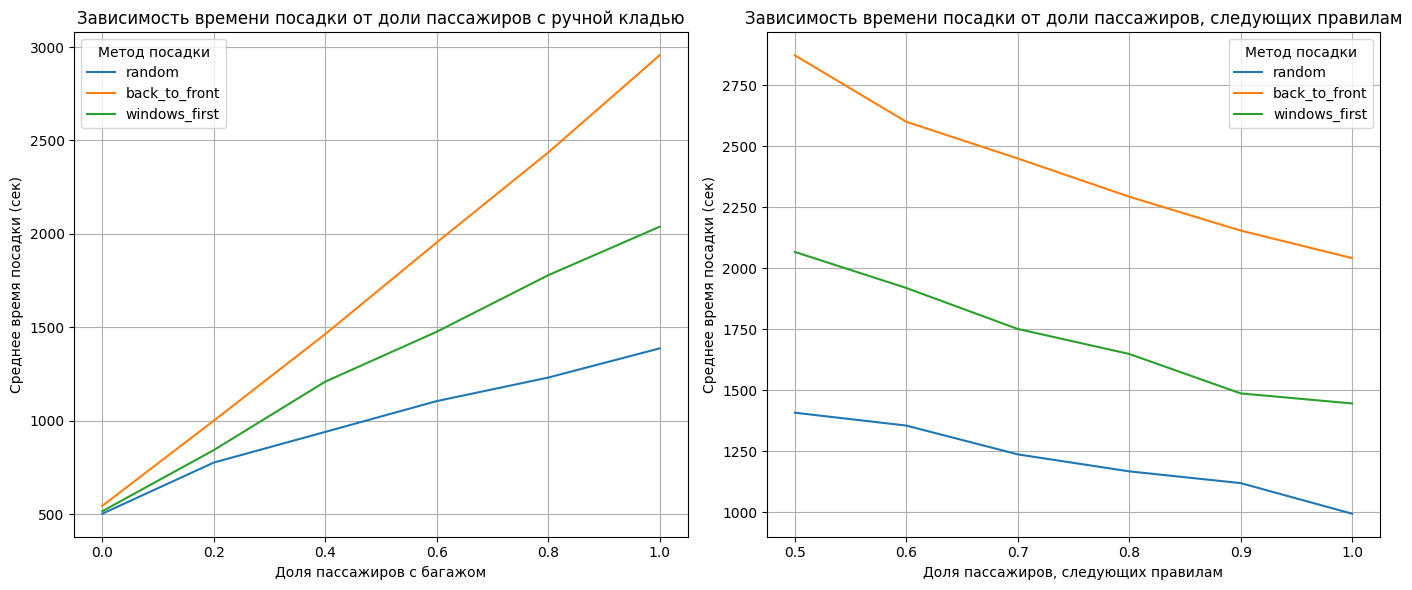

In [ ]:
# ПУНКТ 2: ПРИМЕНЕНИЕ МОДЕЛИ К УЗКОФЮЗЕЛЯЖНОМУ САМОЛЕТУ
# 2.2: АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ 

proportions_of_passengers_with_bag = [0, 0.2, 0.4, 0.6, 0.8, 1]
proportions_of_rules_followers = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
methods = ['random', 'back_to_front', 'windows_first']

bag_results = {}
rules_results = {}

for method in methods:
    bag_results[method] = {}
    rules_results[method] = {}
    for b in proportions_of_passengers_with_bag:
        mean, _, _ = multiple_simulation_runner(method, n=20, bag=b)
        bag_results[method].update({b: mean})
    for rf in proportions_of_rules_followers:
        mean, _, _ = multiple_simulation_runner(method, n=20, following_rules=rf)
        rules_results[method].update({rf: mean})

bag_rows, rules_rows = [], []

for method in bag_results:
    for b, time_ in bag_results[method].items():
        bag_rows.append({'method': method, 'bag': b, 'time': time_})

for method in rules_results:
    for rf, time_ in rules_results[method].items():
        rules_rows.append({'method': method, 'rules_followers': rf, 'time': time_})

bag_df = pd.DataFrame(bag_rows)
rules_df = pd.DataFrame(rules_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2 = axes

bag_plot = sns.lineplot(
    data=bag_df,
    x='bag',
    y='time',
    hue='method',
    ax=ax1
)
ax1.set_title('Зависимость времени посадки от доли пассажиров с ручной кладью')
ax1.set_xlabel('Доля пассажиров с багажом')
ax1.set_ylabel('Среднее время посадки (сек)')
ax1.legend(title='Метод посадки')
ax1.grid(True)

rules_plot = sns.lineplot(
    data=rules_df,
    x='rules_followers',
    y='time',
    hue='method',
    ax=ax2
)
ax2.set_title('Зависимость времени посадки от доли пассажиров, следующих правилам')
ax2.set_xlabel('Доля пассажиров, следующих правилам')
ax2.set_ylabel('Среднее время посадки (сек)')
ax2.legend(title='Метод посадки')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ПУНКТ 2: ПРИМЕНЕНИЕ МОДЕЛИ К УЗКОФЮЗЕЛЯЖНОМУ САМОЛЕТУ
# 2.3: СИТУАЦИЯ С ПЕРЕГРУЗКОЙ БАГАЖА

def passengers_data_creator_overload(
        row_number: int, 
        places_in_row: list[str], 
        bag_probability: float = 0.7,
        following_rules_probability: float = 0.8
        ) -> pd.DataFrame:
    '''
    создает pd.DataFrame с пассажирами, генерируя случайные характеристики 
    '''

    passengers_info = []  =

    for row in range(1, row_number + 1):
        for place in places_in_row:
            if random.random() < bag_probability:  
                has_bag = True 
            else: 
                has_bag = False

            if random.random() < following_rules_probability: 
                follows_rules = True 
            else:
                follows_rules = False 

            passenger_speed = round(max(0.3, np.random.normal(1.2, 0.3)), 1)

            if has_bag:
                baggage_stowage_time = round(max(0.3, np.random.normal(20, 5)), 1)  
            else:
                baggage_stowage_time = 0  

            pass_info = (len(passengers_info) + 1, row, place, has_bag, follows_rules, passenger_speed, baggage_stowage_time)
            passengers_info.append(pass_info)

    COL_NAMES = ['passenger_id', 'row', 'seat', 'has_bag', 'follows_rules', 'passenger_speed', 'baggage_stowage_time']
    PASSENGERS_INFO_TABLE = pd.DataFrame(passengers_info, columns=COL_NAMES)

    return PASSENGERS_INFO_TABLE


results = {}
methods = ['random', 'back_to_front', 'windows_first']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_simulation_runner(method=method, n=25, bag=0.9)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

random: среднее = 1364.00 сек, 5% = 1328.72 сек, 95% = 1399.28 сек
back_to_front: среднее = 2724.00 сек, 5% = 2667.30 сек, 95% = 2780.70 сек
windows_first: среднее = 1903.30 сек, 5% = 1899.16 сек, 95% = 1907.44 сек


## 2.3. Сравнение времени посадки в обычных условиях и при перегрузке багажа

### Результаты

| Метод | Обычные условия (сек) | Перегрузка (сек) | Разница (сек) |
|-------|-----------------------|------------------|---------------|
| random | 1180.87 | 1330.58 | 149.71 |
| back_to_front | 2222.67 | 2692.76 | 470.09 |
| windows_first | 1624.48 | 1931.28 | 306.80 |

- *random*: изменился на **+12.68%**
- *back_to_front*: изменился на **+21.15%**
- *windows_first*: изменился на **+18.89%**

Наибольшее ухудшение показал метод **back_to_front**

Наименьшее ухудшение показал метод **random**.

**Причина увеличения:** при увеличении количества багажа логично, что время всех методов вырастет, т.к. большее количество багажа создаёт дополнительные задержки в проходе.

**Вывод:** при перегрузке багажа рекомендуется метод *random*.

In [ ]:
# ПУНКТ 2: ПРИМЕНЕНИЕ МОДЕЛИ К УЗКОФЮЗЕЛЯЖНОМУ САМОЛЕТУ
# 2.4: ДВА ДОПОЛНИТЕЛЬНЫХ ВОЗМОЖНЫХ МЕТОДА ПОСАДКИ

def boarding_queue_creation(df: pd.DataFrame, boarding_method: str) -> pd.DataFrame:
    ALLOWED_BOARDING_METHODS = [
        'random',  # случайный порядок 
        'back_to_front',  # сортировка по номеру ряда от большего к меньшему
        'windows_first',  # сортировка по типу места: A & F (окна) -> B & E (середина) -> C & D (проход)
        'reverse_pyramid',  # задние окна, потом средние окна, потом передние окна, затем задняя середина, средняя середина, передняя середина, затем задний проход, средний проход, передний проход.
        'steffen'  # окна, потом середина, потом проход: сначала правая сторона нечётных рядов, затем левая сторона чётных, потом сдвиг на пропущенные ряды и так 12 групп от хвоста к носу.
        ]
    
    def windows_first_sorter(seats: pd.Series) -> pd.Series:
        sorted_seats = sorted(seats, key=lambda s: 1 if s in 'AF' else 2 if s in 'BE' else 3)
        return pd.Series(sorted_seats)
    
    def reverse_pyramid_sorter(df: pd.DataFrame) -> pd.DataFrame:
        df['seat_priority'] = df.seat.apply(lambda s: 1 if s in 'AF' else 2 if s in 'BE' else 3)
        df['section_priority'] = df.row.apply(lambda r: 1 if r in range(23, 34) else 2 if r in range(12, 23) else 3)
        sorted_df = df.sort_values(by=['seat_priority', 'section_priority']).reset_index(drop=True)
        sorted_df.drop(['seat_priority', 'section_priority'], axis=1, inplace=True)
        return sorted_df
    
    def get_steffen_priority(row: int, seat: str) -> int:
        PRIORITIES = {
            'even': {
                'A': 2,
                'B': 4,
                'C': 6,
                'D': 11,
                'E': 9,
                'F': 7
            },
            'odd': {
                'A': 8,
                'B': 10,
                'C': 12,
                'D': 5,
                'E': 3,
                'F': 1
            }
        }
        flag = 'even' if not row % 2 else 'odd'
        return PRIORITIES[flag][seat]

    def steffen_sorter(df: pd.DataFrame) -> pd.DataFrame:
        df['priority'] = list(map(lambda cs: get_steffen_priority(cs[0], cs[1]), zip(df.row, df.seat)))
        sorted_df = df.sort_values(by=['priority', 'row'], ascending=[True, False]).reset_index(drop=True)
        sorted_df.drop(['priority'], axis=1, inplace=True)
        return sorted_df 


    boarding_method = boarding_method.strip().lower()

    if boarding_method not in ALLOWED_BOARDING_METHODS:
        raise BoardingQueueError('Boarding method not found. Try again.')

    if boarding_method == 'random':
        result = pd.DataFrame.sample(df, frac=1).reset_index(drop=True)
        return result 
    
    if boarding_method == 'back_to_front':
        result = df.sort_values(by='row', ascending=False).reset_index(drop=True)
        return result 
    
    if boarding_method == 'windows_first': 
        result = df.sort_values(by='seat', key=windows_first_sorter).reset_index(drop=True)
        return result 
    
    if boarding_method == 'reverse_pyramid':
        result = reverse_pyramid_sorter(df)
        return result 
    
    if boarding_method == 'steffen':
        result = steffen_sorter(df)
        return result 
    

results = {}
methods = ['reverse_pyramid', 'steffen']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_simulation_runner(method=method, n=50)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

reverse_pyramid: среднее = 1758.45 сек, 5% = 1658.95 сек, 95% = 1857.94 сек
steffen: среднее = 801.70 сек, 5% = 798.46 сек, 95% = 804.94 сек


## 2.4 Сравнение пяти методов посадки

### Результаты

| Метод | Среднее (сек) | Разброс (сек) | 
|-------|------------|-------------------|
| random | 1180.87 | 214.60 |
| back_to_front | 2222.67 | 423.79 |
| windows_first | 1624.48 | 255.53 |
| reverse_pyramid | 1752.10 | 172.40 |
| steffen | 810.46 | 142.74 |

### Вывод

Лучший метод — **steffen**, так как он показал лучшие результаты по скорости и стабильности.

Рекомендуется метод **steffen** как оптимальный метод посадки.

In [ ]:
# ПУНКТ 2: ПРИМЕНЕНИЕ МОДЕЛИ К УЗКОФЮЗЕЛЯЖНОМУ САМОЛЕТУ
# 2.5: ОПТИМАЛЬНЫЙ МЕТОД ВЫСАДКИ

class DisembarkationError(Exception):
    pass

def disembarkation_strategies_creation(df: pd.DataFrame, disembarkation_method: str) -> pd.DataFrame:
    ALLOWED_DISEMBARKATION_STRATEGIES = [
        'random',
        'front_to_back',  # сортировка по рядам от 1 к 33 (передние выходят первыми)
        'back_to_front',  # сортировка по рядам от 33 к 1 (задние выходят первыми)
        'seat_type'  # проход (C & D) - середина (B & E) - окна (A & F)
    ]

    disembarkation_method = disembarkation_method.strip().lower()

    if disembarkation_method not in ALLOWED_DISEMBARKATION_STRATEGIES:
        raise DisembarkationError
    
    if disembarkation_method == 'random':
        return pd.DataFrame.sample(df, frac=1).reset_index(drop=True)
    
    if disembarkation_method == 'front_to_back':
        sorted_df = df.sort_values(by=['row']).reset_index(drop=True)
        return sorted_df
    
    if disembarkation_method == 'back_to_front':
        sorted_df = df.sort_values(by=['row'], ascending=False).reset_index(drop=True)
        return sorted_df
    
    if disembarkation_method == 'seat_type':
        df['priority'] = df.seat.apply(lambda s: 1 if s in 'CD' else 2 if s in 'BE' else 3)
        sorted_df = df.sort_values(by=['priority']).reset_index(drop=True)
        sorted_df.drop(['priority'], axis=1, inplace=True)
        return sorted_df
    

def multiple_disembarkation_runner(disembarkation_method: str, n: int = 1000) -> tuple:
    '''
    запускает симуляцию n раз возвращает кортеж (среднее время, 5-й перцентиль, 95-й перцентиль)
    '''

    res = []

    for _ in range(n):
        queue = disembarkation_strategies_creation(passengers_data_creator(row_number=NB_ROWS, places_in_row=NB_PLACES), disembarkation_method)
        res.append(run_disembarkation(queue))
    
    return np.mean(res), np.percentile(res, 5), np.percentile(res, 95)


results = {}
methods = ['random', 'front_to_back', 'back_to_front', 'seat_type']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_disembarkation_runner(disembarkation_method=method, n=50)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

random: среднее = 161.69 сек, 5% = 150.28 сек, 95% = 173.50 сек
front_to_back: среднее = 160.93 сек, 5% = 148.88 сек, 95% = 171.89 сек
back_to_front: среднее = 162.12 сек, 5% = 146.53 сек, 95% = 176.07 сек
seat_type: среднее = 164.82 сек, 5% = 157.42 сек, 95% = 176.32 сек


## 2.5 Оптимальный метод высадки

### Результаты

| Метод | Среднее (сек) | Разброс (сек) | 
|-------|------------|-------------------|
| random | 162.11 | 34.93 |
| front_to_back | 160.81 | 32.09 |
| back_to_front | 159.79 | 27.80 |
| seat_type | 161.98 | 29.84 |

### Вывод

Средние времена высадки для всех стратегий близки (разница ~1 сек), что говорит о слабом влиянии порядка высадки при данной модели. Несмотря на это, метод **back_to_front** показал наименьший разброс, поэтому рекомендуется как самый стабильный.

Рекомендуется метод **back_to_front** как оптимальный метод высадки.

In [ ]:
# ПУНКТ 3: МОДИФИКАЦИЯ МОДЕЛИ ДЛЯ ДРУГИХ ТИПОВ САМОЛЁТОВ
# 3.1. САМОЛЕТ "FLYING WING"
# 3.1.1. ПОСАДКА 

flying_wing_info_table = passengers_data_creator(row_number=FW_ROWS, places_in_row=FW_PLACES)

def create_empty_plane_flying_wing() -> tuple[list, list]:
    '''
    создаёт две структуры, описывающие пустой самолёт
    '''

    PLACES_MATRIX = [['free'] * len(FW_PLACES) for _ in range(FW_ROWS)]  # матрица мест
    PASSAGE_MATRIX = ['free' for _ in range(FW_ROWS)]  # 11 рядов (проходов), изначально все свободны 

    return PLACES_MATRIX, PASSAGE_MATRIX


def initialize_simulation_flying_wing(passengers_queue: pd.DataFrame) -> dict[str, Any]:
    '''
    принимает очередь пассажиров и создаёт начальное состояние всей симуляции
    '''

    seat_matrix, aisle_matrix = create_empty_plane_flying_wing()

    state = {
        'time': 0.0,  
        'queue': passengers_queue,  
        'next_queue_index': 0,  
        'active_passengers': [],  
        'seat_matrix': seat_matrix,  
        'aisle_matrix': aisle_matrix,  
        'total_passengers': len(passengers_queue),  
        'boarded_ids': [],   
        'finished': 'no'  
        }  

    return state 


def update_boarding_flying_wing(state: dict[str, Any], time_step: float) -> dict[str, Any]:
    '''
    принимает текущее состояние state и шаг времени time_step (например, 0.1). делает один шаг симуляции и возвращает обновлённое состояние
    '''

    # ЭТАП 1: ЗАПУСК НОВЫХ ПАССАЖИРОВ ИЗ ОЧЕРЕДИ
    while state['aisle_matrix'][0] == 'free' and (state['next_queue_index']) < state['total_passengers']:  # пока свободен проход в первом ряду (вход в самолет) и есть пассажиры в очереди, к-е еще не зашли
        
        df_cur_pass = None 
        index_increase_flag = True

        # логика проверки для тех, кто не следует правилам 
        for _, p in state['queue'].iterrows():
            if not p.follows_rules:
                if not p.passenger_id in state['boarded_ids']:
                    df_cur_pass = p
                    index_increase_flag = False
                    break 

        if df_cur_pass is None:
            df_cur_pass = state['queue'].iloc[state['next_queue_index']]
        
        active_passenger_record = {
            'id': df_cur_pass.passenger_id,
            'target_row': df_cur_pass.row,
            'target_seat': df_cur_pass.seat,
            'current_row': 1,  # текущий ряд для пассажира (он только что зашел в самолет)
            'progress_in_row': 0,  # сколько метров прошел внутри текущего ряда
            'state': 'walking',  # что делает (состояние пассажира)
            'timer': 0,  # таймер для действий 
            'speed': df_cur_pass.passenger_speed,  # скорость пассажира 
            'has_bag': df_cur_pass.has_bag,  # информация о наличии ручной клади 
            'bag_time': df_cur_pass.baggage_stowage_time  # время укладки вещей 
        }  # запись об одном пассажире 

        state['active_passengers'].append(active_passenger_record)  # добавление созданного словаря в список активных пассажиров (те, кто в самолете)
        state['boarded_ids'].append(df_cur_pass.passenger_id)

        state['aisle_matrix'][0] = 'blocked'  # вход занят вошедшим пассажиром 
        if index_increase_flag:
            state['next_queue_index'] += 1  # увеличение счетчика след. пассажира 

    
    # ЭТАП 2: ОБРАБОТКА ВСЕХ АКТИВНЫХ ПАССАЖИРОВ
    for p in state['active_passengers']:  # проход по каждому словарю в списке пассажиров в самолете
        
        if p['state'] == 'walking':
            if p['target_row'] == p['current_row']:  # если уже дошел до своего ряда 
                p['state'] = 'thinking_about_bag'
            else:
                if state['aisle_matrix'][p['current_row']] == 'free':  # если след. ряд свободен
                    p['progress_in_row'] += p['speed'] * time_step  
                    if p['progress_in_row'] >= 1:  # если пассажир прошел 1 ряд (1 метр)
                        old_index = p['current_row'] - 1
                        state['aisle_matrix'][old_index] = 'free'
                        p['current_row'] += 1
                        p['progress_in_row'] -= 1
                        state['aisle_matrix'][p['current_row'] - 1] = 'blocked'

        elif p['state'] == 'thinking_about_bag':
            if p['has_bag'] and p['timer'] == 0:
                p['timer'] = p['bag_time']  
            elif p['has_bag'] and p['timer'] > 0:
                p['timer'] -= time_step
            else:
                p['state'] = 'trying_to_sit' 

        elif p['state'] == 'trying_to_sit':
            base_time = 2  # базовое время на посадку (если путь свободен)
            added_time = 0  # дополнительное время (если места заняты); за каждое занятое место +2 сек
            if p['target_seat'] in 'EF':  # если место в проходе (т.е. путь до него всегда свободен)
                p['timer'] = base_time  
            elif p['target_seat'] in 'DG':   
                seat_index = 4 if p['target_seat'] == 'D' else 5
                if state['seat_matrix'][p['target_row'] - 1][seat_index] == 'occupied':
                    added_time += 2
                p['timer'] = base_time + added_time
            elif p['target_seat'] in 'CH':
                seat_indexes = [3, 4] if p['target_seat'] == 'C' else [5, 6]  
                state_1, state_2 = state['seat_matrix'][p['target_row'] - 1][seat_indexes[0]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[1]]
                if state_1 == 'occupied':
                    added_time += 2
                if state_2 == 'occupied':
                    added_time += 2
                p['timer'] = base_time + added_time
            elif p['target_seat'] in 'BI':
                seat_indexes = [2, 3, 4] if p['target_seat'] == 'B' else [5, 6, 7]  
                state_1, state_2, state_3 = state['seat_matrix'][p['target_row'] - 1][seat_indexes[0]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[1]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[2]]
                added_time = sum(map(lambda s: (s == 'occupied') * 2, [state_1, state_2, state_3]))
                p['timer'] = base_time + added_time
            elif p['target_seat'] in 'AJ':
                seat_indexes = [1, 2, 3, 4] if p['target_seat'] == 'A' else [5, 6, 7, 8]
                state_1, state_2, state_3, state_4 = state['seat_matrix'][p['target_row'] - 1][seat_indexes[0]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[1]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[2]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[3]]
                added_time = sum(map(lambda s: (s == 'occupied') * 2, [state_1, state_2, state_3, state_4]))
                p['timer'] = base_time + added_time
            p['state'] = 'sitting_down'  # пассажир заходит в ряд → проход освобождается
            state['aisle_matrix'][p['current_row'] - 1] = 'free' 
                    

        elif p['state'] == 'sitting_down':
            p['timer'] -= time_step 
            if p['timer'] <= 0:  # если пассажир сел 
                target_seat_index = FW_PLACES.index(p['target_seat'])
                state['seat_matrix'][p['target_row'] - 1][target_seat_index] = 'occupied'  # место занято 
                p['to_remove'] = True  # пассажира нужно удалить из списка тех, кто зашел, т.к. он уже сел

    state['active_passengers'] = [p for p in state['active_passengers'] if not p.get('to_remove')]


    # ЭТАП 3: ПРОВЕРКА ЗАВЕРШЕНИЯ 
    if state['next_queue_index'] == state['total_passengers'] and not state['active_passengers']:  # если все пассажиры из очереди зашли и список активных пассажиров пуст 
        state['finished'] = 'yes'  # завершено

    
    # ЭТАП 4: УВЕЛИЧЕНИЕ ВРЕМЕНИ И ВОЗВРАТ 
    state['time'] += time_step if state['finished'] == 'no' else 0
    return state  # возвращает обновленный словарь состояния 


def run_simulation_flying_wing(passengers_queue: pd.DataFrame, time_step: float=0.1) -> float:
    '''
    запускает симуляцию от начала до конца и возвращает итоговое время запуска
    '''

    state = initialize_simulation_flying_wing(passengers_queue)

    while state['finished'] == 'no':
        state = update_boarding_flying_wing(state, time_step)

    return state['time']


class BoardingQueueError(Exception):
    pass

def boarding_queue_creation_flying_wing(df: pd.DataFrame, boarding_method: str) -> pd.DataFrame:
    ALLOWED_BOARDING_METHODS = [
        'random',  # случайный порядок 
        'back_to_front',  # сортировка по номеру ряда от большего к меньшему
        'windows_first',  # сортировка по типу места: окна -> середина -> проход
        'reverse_pyramid',  # задние окна, потом средние окна, потом передние окна, затем задняя середина, средняя середина, передняя середина, затем задний проход, средний проход, передний проход.
        'steffen'  # окна, потом середина, потом проход: сначала правая сторона нечётных рядов, затем левая сторона чётных, потом сдвиг на пропущенные ряды и так 12 групп от хвоста к носу.
        ]
    
    def windows_first_sorter(seats: pd.Series) -> pd.Series:
        sorted_seats = sorted(seats, key=lambda s: 1 if s in 'AJ' else 2 if s in 'BCDGHI' else 3)
        return pd.Series(sorted_seats)
    
    def reverse_pyramid_sorter(df: pd.DataFrame) -> pd.DataFrame:
        df['seat_priority'] = df.seat.apply(lambda s: 1 if s in 'AJ' else 2 if s in 'BCDGHI' else 3)
        df['section_priority'] = df.row.apply(lambda r: 1 if r in range(8, 12) else 2 if r in range(4, 8) else 3)
        sorted_df = df.sort_values(by=['seat_priority', 'section_priority']).reset_index(drop=True)
        sorted_df.drop(['seat_priority', 'section_priority'], axis=1, inplace=True)
        return sorted_df
    
    def get_steffen_priority(row: int, seat: str) -> int:
        PRIORITIES = {
            'even': {
                'A': 2,
                'B': 6,
                'C': 8,
                'D': 10,
                'E': 18,
                'F': 19,
                'G': 15,
                'H': 13,
                'I': 11,
                'J': 3
            },
            'odd': {
                'A': 4,
                'B': 12,
                'C': 14,
                'D': 16,
                'E': 20,
                'F': 17,
                'G': 9,
                'H': 7,
                'I': 5,
                'J': 1
            }
        }
        flag = 'even' if not row % 2 else 'odd'
        return PRIORITIES[flag][seat]

    def steffen_sorter(df: pd.DataFrame) -> pd.DataFrame:
        df['priority'] = list(map(lambda cs: get_steffen_priority(cs[0], cs[1]), zip(df.row, df.seat)))
        sorted_df = df.sort_values(by=['priority', 'row'], ascending=[True, False]).reset_index(drop=True)
        sorted_df.drop(['priority'], axis=1, inplace=True)
        return sorted_df 


    boarding_method = boarding_method.strip().lower()

    if boarding_method not in ALLOWED_BOARDING_METHODS:
        raise BoardingQueueError('Boarding method not found. Try again.')

    if boarding_method == 'random':
        result = pd.DataFrame.sample(df, frac=1).reset_index(drop=True)
        return result 
    
    if boarding_method == 'back_to_front':
        result = df.sort_values(by='row', ascending=False).reset_index(drop=True)
        return result 
    
    if boarding_method == 'windows_first': 
        result = df.sort_values(by='seat', key=windows_first_sorter).reset_index(drop=True)
        return result 
    
    if boarding_method == 'reverse_pyramid':
        result = reverse_pyramid_sorter(df)
        return result 
    
    if boarding_method == 'steffen':
        result = steffen_sorter(df)
        return result 


def multiple_simulation_runner_flying_wing(
        method: str, 
        n: int = 1000, 
        bag: float = 0.7, 
        following_rules: float = 0.8
        ) -> tuple:
    '''
    запускает симуляцию n раз возвращает кортеж (среднее время, 5-й перцентиль, 95-й перцентиль)
    '''

    res = []

    for _ in range(n):
        queue = boarding_queue_creation_flying_wing(passengers_data_creator(FW_ROWS, FW_PLACES), method)
        res.append(run_simulation_flying_wing(queue))
    
    return np.mean(res), np.percentile(res, 5), np.percentile(res, 95)


results = {}
methods = ['random', 'back_to_front', 'windows_first', 'reverse_pyramid', 'steffen']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_simulation_runner_flying_wing(method=method, n=2)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

random: среднее = 839.05 сек, 5% = 807.15 сек, 95% = 870.96 сек
back_to_front: среднее = 1581.80 сек, 5% = 1458.86 сек, 95% = 1704.74 сек
windows_first: среднее = 972.95 сек, 5% = 942.94 сек, 95% = 1002.97 сек
reverse_pyramid: среднее = 1228.80 сек, 5% = 1205.58 сек, 95% = 1252.02 сек
steffen: среднее = 707.20 сек, 5% = 703.60 сек, 95% = 710.80 сек


## 3.1. Сравнение пяти методов посадки для самолета Flying Wing 

### Результаты

| Метод | Среднее (сек) | Разброс (сек) | 
|-------|------------|-------------------|
| random | 849.75 | 214.30 |
| back_to_front | 1364.08 | 324.70 |
| windows_first | 987.86 | 269.88 |
| reverse_pyramid | 1180.35 | 314.50 |
| steffen | 650.32 | 126.70 |

### Вывод

Лучший метод — **steffen**, так как он показал лучшие результаты по скорости и стабильности.

Рекомендуется метод **steffen** как оптимальный метод посадки.

In [ ]:
# 3.1.2. ВЫСАДКА 

def create_full_plane_flying_wing() -> tuple[list, list]:
    '''
    создает матрицу мест, где все места заняты, и матрицу прохода, где все проходы свободны
    возвращает кортеж из этих матриц
    '''
    OCCUPIED_PLACES_MATRIX = [['occupied'] * len(FW_PLACES) for _ in range(FW_ROWS)]
    PASSAGE_MATRIX = ['free' for _ in range(FW_ROWS)]

    return OCCUPIED_PLACES_MATRIX, PASSAGE_MATRIX


def initialize_disembarkation_flying_wing(passengers_data: pd.DataFrame) -> dict[str, Any]:
    '''
    создает состояние для высадки 
    '''
    
    seat_matrix, aisle_matrix = create_full_plane_flying_wing()

    active_passengers = []

    for _, p in passengers_data.iterrows(): 
        p_state = {
            'id': p.passenger_id,
            'row': p.row,
            'seat': p.seat,
            'current_row': p.row,  # равен целевому ряду, т.к. пассажир начинает движение из своего ряда 
            'state': 'sitting',  # в начале все сидят 
            'timer': 0,  # пока нет активных действий 
            'speed': p.passenger_speed,
            'has_bag': p.has_bag,
            'bag_time': p.baggage_stowage_time,
            'progress_in_row': 0  # сколько метров прошел внутри ряда
        }

        active_passengers.append(p_state)

    shuffle(active_passengers)

    state = {
        'time': 0,  # текущее время симуляции, изначально 0
        'active_passengers': active_passengers,
        'seat_matrix': seat_matrix,
        'aisle_matrix': aisle_matrix,
        'total_passengers': len(passengers_data),
        'finished': 'no'
    }  # в высадке нет полей 'queue' и 'next_queue_index', потому что очередь на вход не нужна — все уже внутри

    return state 


def update_disembarkation_flying_wing(state: dict[str, Any], time_step: float) -> dict[str, Any]:
    '''
    принимает текущее состояние state и шаг времени time_step (например, 0.1). делает один шаг симуляции и возвращает обновлённое состояние
    '''

    for p in state['active_passengers']:
        if p['state'] == 'sitting':  # если пассажир сидит на месте (хочет встать и пойти к выходу)
            if state['aisle_matrix'][p['row'] - 1] == 'free':  
                if p['has_bag']:  
                    p['state'] = 'collecting_bag' 
                    p['timer'] = p['bag_time'] 
                    
                else:
                    p['state'] = 'walking_to_exit'  # если нет багажа, сразу идет к выходу
                    state['aisle_matrix'][p['row'] - 1] = 'blocked'
                state['seat_matrix'][p['row'] - 1][FW_PLACES.index(p['seat'])] = 'free'

        elif p['state'] == 'collecting_bag':  # если достает багаж 
            p['timer'] -= time_step
            if p['timer'] <= 0:  
                if state['aisle_matrix'][p['row'] - 1] == 'free':
                    p['state'] = 'walking_to_exit'
                    state['aisle_matrix'][p['row'] - 1] = 'blocked'

        elif p['state'] == 'walking_to_exit':  # если идет к выходу 
            if p['current_row'] == 1:
                p['progress_in_row'] += p['speed'] * time_step
                if p['progress_in_row'] >= 1:
                    state['aisle_matrix'][0] = 'free'
                    p['to_remove'] = True 
                    p['progress_in_row'] -= 1
            else:
                if state['aisle_matrix'][p['current_row'] - 2] == 'free': 
                    p['progress_in_row'] += p['speed'] * time_step
                    if p['progress_in_row'] >= 1:
                        state['aisle_matrix'][p['current_row'] - 1] = 'free'  # **
                        state['aisle_matrix'][p['current_row'] - 2] = 'blocked'
                        p['current_row'] -= 1
                        

    state['active_passengers'] = [p for p in state['active_passengers'] if not p.get('to_remove')]  # проход по списку активных пассажиров и удаление тех, кто помечен как вышедший 

    if not state['active_passengers']:
        state['time'] += time_step
        state['finished'] = 'yes'

    if state['finished'] == 'no':
        state['time'] += time_step

    return state 


def run_disembarkation_flying_wing(passengers_data: pd.DataFrame, time_step: float=0.1) -> float:
    '''
    запускает симуляцию от начала до конца и возвращает итоговое время высадки
    '''
    
    state = initialize_disembarkation_flying_wing(passengers_data)

    while state['finished'] == 'no':
        state = update_disembarkation_flying_wing(state, time_step)

    return state['time']


class DisembarkationError(Exception):
    pass

def disembarkation_strategies_creation_flying_wing(df: pd.DataFrame, disembarkation_method: str) -> pd.DataFrame:
    ALLOWED_DISEMBARKATION_STRATEGIES = [
        'random',
        'front_to_back',  # сортировка по рядам от 1 к 11 (передние выходят первыми)
        'back_to_front',  # сортировка по рядам от 11 к 1 (задние выходят первыми)
        'seat_type'  # проход - середина - окна 
    ]

    disembarkation_method = disembarkation_method.strip().lower()

    if disembarkation_method not in ALLOWED_DISEMBARKATION_STRATEGIES:
        raise DisembarkationError
    
    if disembarkation_method == 'random':
        return pd.DataFrame.sample(df, frac=1).reset_index(drop=True)
    
    if disembarkation_method == 'front_to_back':
        sorted_df = df.sort_values(by=['row']).reset_index(drop=True)
        return sorted_df
    
    if disembarkation_method == 'back_to_front':
        sorted_df = df.sort_values(by=['row'], ascending=False).reset_index(drop=True)
        return sorted_df
    
    if disembarkation_method == 'seat_type':
        df['priority'] = df.seat.apply(lambda s: 1 if s in 'EF' else 2 if s in 'BCDGHI' else 3)
        sorted_df = df.sort_values(by=['priority']).reset_index(drop=True)
        sorted_df.drop(['priority'], axis=1, inplace=True)
        return sorted_df
    

def multiple_disembarkation_runner_flying_wing(disembarkation_method: str, n: int = 1000) -> tuple:
    '''
    запускает симуляцию n раз возвращает кортеж (среднее время, 5-й перцентиль, 95-й перцентиль)
    '''

    res = []

    for _ in range(n):
        queue = disembarkation_strategies_creation_flying_wing(flying_wing_info_table, disembarkation_method)
        res.append(run_disembarkation_flying_wing(queue))
    
    return np.mean(res), np.percentile(res, 5), np.percentile(res, 95)


results = {}
methods = ['random', 'front_to_back', 'back_to_front', 'seat_type']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_disembarkation_runner_flying_wing(disembarkation_method=method, n=100)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

random: среднее = 107.25 сек, 5% = 98.53 сек, 95% = 112.00 сек
front_to_back: среднее = 105.90 сек, 5% = 97.23 сек, 95% = 112.51 сек
back_to_front: среднее = 106.59 сек, 5% = 96.27 сек, 95% = 113.00 сек
seat_type: среднее = 105.95 сек, 5% = 95.46 сек, 95% = 112.80 сек


## 3.1. Оптимальный метод высадки для самолета Flying Wing 

### Результаты

| Метод | Среднее (сек) | Разброс (сек) | 
|-------|------------|-------------------|
| random | 105.67 | 16.72 |
| front_to_back | 105.01 | 16.04 |
| back_to_front | 104.44 | 18.51 |
| seat_type | 105.19 | 16.51 |

### Вывод

Средние времена высадки для всех стратегий близки (разница ~1 сек), что говорит о слабом влиянии порядка высадки при данной модели. Несмотря на это, метод **front_to_back** показал наименьший разброс, поэтому рекомендуется как самый стабильный.

Рекомендуется метод **front_to_back** как оптимальный метод высадки вследствие максимальной стабильности и логики.

In [ ]:
# ПУНКТ 3: МОДИФИКАЦИЯ МОДЕЛИ ДЛЯ ДРУГИХ ТИПОВ САМОЛЁТОВ
# 3.2. САМОЛЕТ "TWO-ENTRANCE TWO-AISLE"
# 3.2.1. ПОСАДКА 

te_ta_info_table = passengers_data_creator(BO_ROWS, BO_PLACES)

def create_empty_plane_boeing() -> tuple[list, list]:
    '''
    создаёт две структуры, описывающие пустой самолёт
    '''

    PLACES_MATRIX = [['free'] * len(BO_PLACES) for _ in range(BO_ROWS)]  # матрица мест
    PASSAGE_MATRIX = [['free' for _ in range(BO_ROWS)] for _ in range(2)]  # двумерная матрица для двух проходов 

    return PLACES_MATRIX, PASSAGE_MATRIX


def initialize_simulation_boeing(passengers_queue: pd.DataFrame) -> dict[str, Any]:
    '''
    принимает очередь пассажиров и создаёт начальное состояние всей симуляции
    '''

    seat_matrix, aisle_matrix = create_empty_plane_boeing()

    state = {
        'time': 0.0,  # число, текущее время симуляции
        'queue': passengers_queue,  # пассажиры, к-е ещё не зашли в самолёт
        'next_queue_index': 0,  # индекс следующего пассажира в списке queue
        'active_passengers': [],  # пустой список пассажиров, к-е уже в самолёте
        'seat_matrix': seat_matrix,  # матрица мест
        'aisle_matrix': aisle_matrix,  # матрица прохода
        'total_passengers': len(passengers_queue),  # общее число пассажиров -- длина списка queue
        'boarded_ids': [],  # список id пассажиров, зашедших в самолет 
        'finished': 'no'  # флаг завершения симуляции 
    }  # словарь с информацией о симуляции 

    return state 


def update_boarding_boeing(state: dict[str, Any], time_step: float) -> dict[str, Any]:
    '''
    принимает текущее состояние state и шаг времени time_step (например, 0.1). делает один шаг симуляции и возвращает обновлённое состояние
    '''

    # ЭТАП 1: ЗАПУСК НОВЫХ ПАССАЖИРОВ ИЗ ОЧЕРЕДИ
    front_left_entrance = state['aisle_matrix'][0][0] == 'free'
    front_right_entrance = state['aisle_matrix'][1][0] == 'free'
    back_left_entrance = state['aisle_matrix'][0][46] == 'free'
    back_right_entrance = state['aisle_matrix'][1][46] == 'free'

    while (front_left_entrance or front_right_entrance or back_left_entrance or back_right_entrance) and (state['next_queue_index']) < state['total_passengers']:  # пока свободен какой-то из входов и есть пассажиры в очереди, к-е еще не зашли
        
        df_cur_pass = None 
        index_increase_flag = True

        # логика проверки для тех, кто не следует правилам 
        for _, p in state['queue'].iterrows():
            if not p.follows_rules:
                if not p.passenger_id in state['boarded_ids']:
                    df_cur_pass = p
                    index_increase_flag = False
                    break 

        if df_cur_pass is None:
            df_cur_pass = state['queue'].iloc[state['next_queue_index']]
        
        active_passenger_record = {
            'id': df_cur_pass.passenger_id,
            'target_row': df_cur_pass.row,
            'target_seat': df_cur_pass.seat,
            'current_row': 1 if df_cur_pass.row in range(1, 24) else 47,  # текущий ряд для пассажира (он только что зашел в самолет)
            'progress_in_row': 0,  # сколько метров прошел внутри текущего ряда
            'state': 'walking',  # что делает (состояние пассажира)
            'timer': 0,  # таймер для действий 
            'speed': df_cur_pass.passenger_speed,  # скорость пассажира 
            'has_bag': df_cur_pass.has_bag,  # информация о наличии ручной клади 
            'bag_time': df_cur_pass.baggage_stowage_time,  # время укладки вещей 
            'entrance': 1 if df_cur_pass.row in range(1, 24) else 47,  # вход: если таргет ряд пассажира в диапазоне 1-23 --> заходит с переднего входа, иначе --> с заднего 
            'aisle_idx': 0 if df_cur_pass.seat in 'ABCD' else 1,  # левый / правый проход: если место пассажира в 'ABCD' --> левый, иначе --> правый 
            'direction': +1 if df_cur_pass.row in range(1, 24) else -1  # направление движения: +1 --> от переда к хвосту, -1 --> от хвоста к переду 
        }  # запись об одном пассажире 

        state['active_passengers'].append(active_passenger_record)  # добавление созданного словаря в список активных пассажиров (те, кто в самолете)
        state['boarded_ids'].append(df_cur_pass.passenger_id)

        state['aisle_matrix'][active_passenger_record['aisle_idx']][active_passenger_record['entrance'] - 1] = 'blocked'  # вход занят вошедшим пассажиром 
        if index_increase_flag:
            state['next_queue_index'] += 1  # увеличение счетчика след. пассажира 

    
    # ЭТАП 2: ОБРАБОТКА ВСЕХ АКТИВНЫХ ПАССАЖИРОВ
    for p in state['active_passengers']:  # проход по каждому словарю в списке пассажиров в самолете
        
        if p['state'] == 'walking':
            if p['target_row'] == p['current_row']:  
                p['state'] = 'thinking_about_bag'
            else:
                next_row = p['current_row'] + p['direction']
                if state['aisle_matrix'][p['aisle_idx']][next_row - 1] == 'free':  
                    p['progress_in_row'] += p['speed'] * time_step  
                    if p['progress_in_row'] >= 1:  
                        old_index = p['current_row'] - 1
                        new_index = next_row - 1
                        state['aisle_matrix'][p['aisle_idx']][old_index] = 'free'
                        p['current_row'] = next_row
                        p['progress_in_row'] -= 1
                        state['aisle_matrix'][p['aisle_idx']][new_index] = 'blocked'

        elif p['state'] == 'thinking_about_bag':
            if p['has_bag'] and p['timer'] == 0:
                p['timer'] = p['bag_time']  
            elif p['has_bag'] and p['timer'] > 0:
                p['timer'] -= time_step
            else:
                p['state'] = 'trying_to_sit' 

        elif p['state'] == 'trying_to_sit':
            base_time = 2  # базовое время на посадку (если путь свободен)
            added_time = 0  # дополнительное время (если места заняты); за каждое занятое место +2 сек
            if p['target_seat'] in 'BCEF':  
                p['timer'] = base_time   
            elif p['target_seat'] in 'AG':   
                seat_index = 1 if p['target_seat'] == 'A' else 5  
                if state['seat_matrix'][p['target_row'] - 1][seat_index] == 'occupied':
                    added_time += 2
                p['timer'] = base_time + added_time
            elif p['target_seat'] == 'D':
                seat_indexes = [2, 4]
                state_1, state_2 = state['seat_matrix'][p['target_row'] - 1][seat_indexes[0]], state['seat_matrix'][p['target_row'] - 1][seat_indexes[1]]
                if state_1 == 'occupied':
                    added_time += 2
                if state_2 == 'occupied':
                    added_time += 2
                p['timer'] = base_time + added_time
            p['state'] = 'sitting_down'  # пассажир заходит в ряд → проход освобождается
            state['aisle_matrix'][p['aisle_idx']][p['current_row'] - 1] = 'free' 
                    

        elif p['state'] == 'sitting_down':
            p['timer'] -= time_step  
            if p['timer'] <= 0:  # если пассажир сел 
                target_seat_index = BO_PLACES.index(p['target_seat'])
                state['seat_matrix'][p['target_row'] - 1][target_seat_index] = 'occupied'  # место занято 
                p['to_remove'] = True  # пассажира нужно удалить из списка тех, кто зашел, т.к. он уже сел

    state['active_passengers'] = [p for p in state['active_passengers'] if not p.get('to_remove')]


    # ЭТАП 3: ПРОВЕРКА ЗАВЕРШЕНИЯ 
    if state['next_queue_index'] == state['total_passengers'] and not state['active_passengers']:  # если все пассажиры из очереди зашли и список активных пассажиров пуст 
        state['finished'] = 'yes'  # завершено

    
    # ЭТАП 4: УВЕЛИЧЕНИЕ ВРЕМЕНИ И ВОЗВРАТ 
    state['time'] += time_step if state['finished'] == 'no' else 0
    return state  # возвращает обновленный словарь состояния 


def run_simulation_boeing(passengers_queue: pd.DataFrame, time_step: float=0.1) -> float:
    '''
    запускает симуляцию от начала до конца и возвращает итоговое время запуска
    '''

    state = initialize_simulation_boeing(passengers_queue)

    while state['finished'] == 'no':
        state = update_boarding_boeing(state, time_step)

    return state['time']


class BoardingQueueError(Exception):
    pass

def boarding_queue_creation_boeing(df: pd.DataFrame, boarding_method: str) -> pd.DataFrame:
    ALLOWED_BOARDING_METHODS = [
        'random',  # случайный порядок 
        'back_to_front',  # сортировка по номеру ряда от большего к меньшему
        'windows_first',  # сортировка по типу места: окна -> середина -> проход
        'reverse_pyramid',  # задние окна, потом средние окна, потом передние окна, затем задняя середина, средняя середина, передняя середина, затем задний проход, средний проход, передний проход.
        'steffen'  # окна, потом середина, потом проход: сначала правая сторона нечётных рядов, затем левая сторона чётных, потом сдвиг на пропущенные ряды и так 12 групп от хвоста к носу.
        ]
    
    def windows_first_sorter(seats: pd.Series) -> pd.Series:
        sorted_seats = sorted(seats, key=lambda s: 1 if s in 'AG' else 2 if s in 'CDE' else 3)
        return pd.Series(sorted_seats)
    
    def reverse_pyramid_sorter(df: pd.DataFrame) -> pd.DataFrame:
        df['seat_priority'] = df.seat.apply(lambda s: 1 if s in 'AG' else 2 if s in 'CDE' else 3)
        df['section_priority'] = df.row.apply(lambda r: 1 if r in range(32, 48) else 2 if r in range(17, 32) else 3)
        sorted_df = df.sort_values(by=['seat_priority', 'section_priority']).reset_index(drop=True)
        sorted_df.drop(['seat_priority', 'section_priority'], axis=1, inplace=True)
        return sorted_df
    
    def get_steffen_priority(row: int, seat: str) -> int:
        PRIORITIES = {
            'even': {
                'A': 2,
                'B': 11,
                'C': 5,
                'D': 6,
                'E': 7,
                'F': 12,
                'G': 3,
            },
            'odd': {
                'A': 4,
                'B': 14,
                'C': 8,
                'D': 10,
                'E': 9,
                'F': 13,
                'G': 1,
            }
        }
        flag = 'even' if not row % 2 else 'odd'
        return PRIORITIES[flag][seat]

    def steffen_sorter(df: pd.DataFrame) -> pd.DataFrame:
        df['priority'] = list(map(lambda cs: get_steffen_priority(cs[0], cs[1]), zip(df.row, df.seat)))
        sorted_df = df.sort_values(by=['priority', 'row'], ascending=[True, False]).reset_index(drop=True)
        sorted_df.drop(['priority'], axis=1, inplace=True)
        return sorted_df 


    boarding_method = boarding_method.strip().lower()

    if boarding_method not in ALLOWED_BOARDING_METHODS:
        raise BoardingQueueError('Boarding method not found. Try again.')

    if boarding_method == 'random':
        result = pd.DataFrame.sample(df, frac=1).reset_index(drop=True)
        return result 
    
    if boarding_method == 'back_to_front':
        result = df.sort_values(by='row', ascending=False).reset_index(drop=True)
        return result 
    
    if boarding_method == 'windows_first': 
        result = df.sort_values(by='seat', key=windows_first_sorter).reset_index(drop=True)
        return result 
    
    if boarding_method == 'reverse_pyramid':
        result = reverse_pyramid_sorter(df)
        return result 
    
    if boarding_method == 'steffen':
        result = steffen_sorter(df)
        return result 


def multiple_simulation_runner_boeing(
        method: str, 
        n: int = 1000, 
        bag: float = 0.7, 
        following_rules: float = 0.8
        ) -> tuple:
    '''
    запускает симуляцию n раз возвращает кортеж (среднее время, 5-й перцентиль, 95-й перцентиль)
    '''

    res = []

    for _ in range(n):
        queue = boarding_queue_creation_boeing(passengers_data_creator(BO_ROWS, BO_PLACES), method)
        res.append(run_simulation_boeing(queue))
    
    return np.mean(res), np.percentile(res, 5), np.percentile(res, 95)


results = {}

methods = ['random', 'back_to_front', 'windows_first', 'reverse_pyramid', 'steffen']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_simulation_runner_boeing(method=method, n=20)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

random: среднее = 621.69 сек, 5% = 556.68 сек, 95% = 696.71 сек
back_to_front: среднее = 707.10 сек, 5% = 606.70 сек, 95% = 802.14 сек
windows_first: среднее = 606.48 сек, 5% = 543.25 сек, 95% = 665.38 сек
reverse_pyramid: среднее = 642.75 сек, 5% = 573.79 сек, 95% = 728.38 сек
steffen: среднее = 613.85 сек, 5% = 575.61 сек, 95% = 692.89 сек


## 3.2. Сравнение пяти методов посадки для самолета Two-Entrance Two-Aisle

### Результаты

| Метод | Среднее (сек) | Разброс (сек) | 
|-------|------------|-------------------|
| random | 621.69 | 140.03 |
| back_to_front | 707.10 | 195.44 |
| windows_first | 606.48 | 122.13 |
| reverse_pyramid | 642.75 | 154.59 |
| steffen | 613.85 | 117.28 |

### Вывод

Лучший метод — **windows_first**, так как он показал лучшие результаты по скорости и достаточную стабильность.

Рекомендуется метод **windows_first** как оптимальный метод посадки.

In [ ]:
# 3.2.2. ВЫСАДКА 

def create_full_plane_boeing() -> tuple[list, list]:
    '''
    создает матрицу мест, где все места заняты, и матрицу прохода, где все проходы свободны
    возвращает кортеж из этих матриц
    '''
    OCCUPIED_PLACES_MATRIX = [['occupied'] * len(BO_PLACES) for _ in range(BO_ROWS)]
    PASSAGE_MATRIX = [['free' for _ in range(BO_ROWS)] for _ in range(2)]

    return OCCUPIED_PLACES_MATRIX, PASSAGE_MATRIX


def initialize_disembarkation_boeing(passengers_data: pd.DataFrame) -> dict[str, Any]:
    '''
    создает состояние для высадки 
    '''
    
    seat_matrix, aisle_matrix = create_full_plane_boeing()

    active_passengers = []

    for _, p in passengers_data.iterrows(): 
        p_state = {
            'id': p.passenger_id,
            'row': p.row,
            'seat': p.seat,
            'current_row': p.row,  # равен целевому ряду, т.к. пассажир начинает движение из своего ряда 
            'state': 'sitting',  # в начале все сидят 
            'timer': 0,  # пока нет активных действий 
            'speed': p.passenger_speed,
            'has_bag': p.has_bag,
            'bag_time': p.baggage_stowage_time,
            'progress_in_row': 0,  # сколько метров прошел внутри ряда
            'aisle_idx': 0 if p.seat in 'ABCD' else 1,
            'tgt_exit_row': 1 if p.row in range(1, 24) else 47,  # ближайший выход 
            'direction': -1 if p.row in range(1, 24) else +1  # направление движения 
        }

        active_passengers.append(p_state)

    shuffle(active_passengers)

    state = {
        'time': 0,  # текущее время симуляции, изначально 0
        'active_passengers': active_passengers,
        'seat_matrix': seat_matrix,
        'aisle_matrix': aisle_matrix,
        'total_passengers': len(passengers_data),
        'finished': 'no'
    }  # в высадке нет полей 'queue' и 'next_queue_index', потому что очередь на вход не нужна — все уже внутри

    return state 


def update_disembarkation_boeing(state: dict[str, Any], time_step: float) -> dict[str, Any]:
    '''
    принимает текущее состояние state и шаг времени time_step (например, 0.1). делает один шаг симуляции и возвращает обновлённое состояние
    '''

    for p in state['active_passengers']:
        if p['state'] == 'sitting':  # если пассажир сидит на месте (хочет встать и пойти к выходу)
            if state['aisle_matrix'][p['aisle_idx']][p['row'] - 1] == 'free':  # если проход пассажира свободен 
                if p['has_bag']:  
                    p['state'] = 'collecting_bag' 
                    p['timer'] = p['bag_time'] 
                    
                else:
                    p['state'] = 'walking_to_exit'  # если нет багажа, сразу идет к выходу
                    state['aisle_matrix'][p['aisle_idx']][p['row'] - 1] = 'blocked'
                state['seat_matrix'][p['row'] - 1][BO_PLACES.index(p['seat'])] = 'free'

        elif p['state'] == 'collecting_bag':  # если достает багаж 
            p['timer'] -= time_step
            if p['timer'] <= 0:  # если достал сумки 
                if state['aisle_matrix'][p['aisle_idx']][p['row'] - 1] == 'free':
                    p['state'] = 'walking_to_exit'
                    state['aisle_matrix'][p['aisle_idx']][p['row'] - 1] = 'blocked'

        elif p['state'] == 'walking_to_exit':  # если идет к выходу 
            if p['current_row'] == p['tgt_exit_row']:
                p['progress_in_row'] += p['speed'] * time_step
                if p['progress_in_row'] >= 1:
                    state['aisle_matrix'][p['aisle_idx']][p['tgt_exit_row'] - 1] = 'free'
                    p['to_remove'] = True 
                    p['progress_in_row'] -= 1
            else:
                next_row = p['current_row'] + p['direction']
                if state['aisle_matrix'][p['aisle_idx']][next_row - 1] == 'free': 
                    p['progress_in_row'] += p['speed'] * time_step
                    if p['progress_in_row'] >= 1:
                        state['aisle_matrix'][p['aisle_idx']][p['current_row'] - 1] = 'free' 
                        state['aisle_matrix'][p['aisle_idx']][next_row - 1] = 'blocked'
                        p['current_row'] = next_row
                        

    state['active_passengers'] = [p for p in state['active_passengers'] if not p.get('to_remove')]  # проход по списку активных пассажиров и удаление тех, кто помечен как вышедший 

    if not state['active_passengers']:
        state['time'] += time_step
        state['finished'] = 'yes'

    if state['finished'] == 'no':
        state['time'] += time_step

    return state 


def run_disembarkation_boeing(passengers_data: pd.DataFrame, time_step: float=0.1) -> float:
    '''
    запускает симуляцию от начала до конца и возвращает итоговое время высадки
    '''
    
    state = initialize_disembarkation_boeing(passengers_data)

    while state['finished'] == 'no':
        state = update_disembarkation_boeing(state, time_step)

    return state['time']


class DisembarkationError(Exception):
    pass

def disembarkation_strategies_creation_boeing(df: pd.DataFrame, disembarkation_method: str) -> pd.DataFrame:
    ALLOWED_DISEMBARKATION_STRATEGIES = [
        'random',
        'front_to_back',  # сортировка по рядам от 1 к 47 (передние выходят первыми)
        'back_to_front',  # сортировка по рядам от 47 к 1 (задние выходят первыми)
        'seat_type'  # проход - середина - окна 
    ]

    disembarkation_method = disembarkation_method.strip().lower()

    if disembarkation_method not in ALLOWED_DISEMBARKATION_STRATEGIES:
        raise DisembarkationError
    
    if disembarkation_method == 'random':
        return pd.DataFrame.sample(df, frac=1).reset_index(drop=True)
    
    if disembarkation_method == 'front_to_back':
        sorted_df = df.sort_values(by=['row']).reset_index(drop=True)
        return sorted_df
    
    if disembarkation_method == 'back_to_front':
        sorted_df = df.sort_values(by=['row'], ascending=False).reset_index(drop=True)
        return sorted_df
    
    if disembarkation_method == 'seat_type':
        df['priority'] = df.seat.apply(lambda s: 1 if s in 'BF' else 2 if s in 'CDE' else 3)
        sorted_df = df.sort_values(by=['priority']).reset_index(drop=True)
        sorted_df.drop(['priority'], axis=1, inplace=True)
        return sorted_df
    

def multiple_disembarkation_runner_boeing(disembarkation_method: str, n: int = 1000) -> tuple:
    '''
    запускает симуляцию n раз возвращает кортеж (среднее время, 5-й перцентиль, 95-й перцентиль)
    '''

    res = []

    for _ in range(n):
        queue = disembarkation_strategies_creation_boeing(passengers_data_creator(BO_ROWS, BO_PLACES), disembarkation_method)
        res.append(run_disembarkation_boeing(queue))
    
    return np.mean(res), np.percentile(res, 5), np.percentile(res, 95)


results = {}
methods = ['random', 'front_to_back', 'back_to_front', 'seat_type']
for method in methods:
    mean, percentile_5, percentile_95 = multiple_disembarkation_runner_boeing(disembarkation_method=method, n=100)
    print(f'{method}: среднее = {mean:.2f} сек, 5% = {percentile_5:.2f} сек, 95% = {percentile_95:.2f} сек')
    results[method] = {'mean': mean, 'percentile_5': percentile_5, 'percentile_95': percentile_95}

random: среднее = 75.59 сек, 5% = 62.84 сек, 95% = 87.78 сек
front_to_back: среднее = 76.72 сек, 5% = 62.99 сек, 95% = 91.13 сек
back_to_front: среднее = 77.78 сек, 5% = 63.70 сек, 95% = 90.03 сек
seat_type: среднее = 77.39 сек, 5% = 65.64 сек, 95% = 89.13 сек


## 3.2. Оптимальный метод высадки для самолета Two-Entrance Two-Aisle 

### Результаты

| Метод | Среднее (сек) | Разброс (сек) | 
|-------|------------|-------------------|
| random | 76.00 | 27.17 |
| front_to_back | 77.33 | 27.44 |
| back_to_front | 77.48 | 25.16 |
| seat_type | 77.06 | 27.62 |

### Вывод

Средние времена высадки для всех стратегий близки (разница ~1 сек), что говорит о слабом влиянии порядка высадки при данной модели. Несмотря на это, метод **front_to_back** допустимо считать самым логичным; также он имеет сравнительно небольшой разброс.

Рекомендуется метод **front_to_back** как оптимальный метод высадки вследствие хорошей стабильности и логики.

In [ ]:
# ПУНКТ 4: ОГРАНИЧЕНИЯ ПО ЗАГРУЗКЕ ИЗ-ЗА ПАНДЕМИИ 

planes = [
    {   'type': 'narrow_body',   
        'rn': NB_ROWS,
        'places': NB_PLACES,
        'landing': 'steffen',
        'disembarkation': 'back_to_front',
        'runner_l': multiple_simulation_runner,
        'runner_d': multiple_disembarkation_runner
    },
    {   'type': 'flying_wing',
        'rn': FW_ROWS,
        'places': FW_PLACES,
        'landing': 'steffen',
        'disembarkation': 'front_to_back',
        'runner_l': multiple_simulation_runner_flying_wing,
        'runner_d': multiple_disembarkation_runner_flying_wing
    },
    {   'type': 'two_entrance_to_aisle',
        'rn': BO_ROWS,
        'places': BO_PLACES,
        'landing': 'windows_first',
        'disembarkation': 'front_to_back',
        'runner_l': multiple_simulation_runner_boeing,
        'runner_d': multiple_disembarkation_runner_boeing
    }
]

load_factors = [1.0, 0.7, 0.5, 0.3]
methods_l = ['random', 'back_to_front', 'windows_first', 'reverse_pyramid', 'steffen']
methods_d = ['random', 'front_to_back', 'back_to_front', 'seat_type']

print('=== ПОСАДКА ===')
for plane in planes:
    method_l = plane['landing']
    print(f'--- {plane['type'].upper()} | ЛУЧШИЙ МЕТОД: {method_l.upper()} ---')
    for lf in load_factors:
        df = passengers_data_creator(row_number=plane['rn'], places_in_row=plane['places'], load_factor=lf)
        runner_l = plane['runner_l']
        
        for ml in methods_l:
            mean_l, percentile_5_l, percentile_95_l = runner_l(ml, n=20)
            print(f'ЗАГРУЗКА: {int(lf * 100)}% | МЕТОД: {ml} | среднее = {mean_l:.2f} сек, разброс = {percentile_95_l - percentile_5_l:.2f} сек')
        print('\n')

print('=== ВЫСАДКА ===')
for plane in planes:
    method_d = plane['disembarkation']
    print(f'--- {plane['type'].upper()} | ЛУЧШИЙ МЕТОД: {method_d.upper()} ---')
    for lf in load_factors:
        df = passengers_data_creator(row_number=plane['rn'], places_in_row=plane['places'], load_factor=lf)
        runner_d = plane['runner_d']

        for md in methods_d:
            mean_d, percentile_5_d, percentile_95_d = runner_d(md, n=20)
            print(f'ЗАГРУЗКА: {int(lf * 100)}% | МЕТОД: {md} | среднее = {mean_d:.2f} сек, разброс = {percentile_95_d - percentile_5_d:.2f} сек')
    print('\n')

=== ПОСАДКА ===
--- NARROW_BODY | ЛУЧШИЙ МЕТОД: STEFFEN ---
ЗАГРУЗКА: 100% | МЕТОД: random | среднее = 1171.37 сек, разброс = 164.70 сек
ЗАГРУЗКА: 100% | МЕТОД: back_to_front | среднее = 2233.97 сек, разброс = 260.45 сек
ЗАГРУЗКА: 100% | МЕТОД: windows_first | среднее = 1616.91 сек, разброс = 268.39 сек
ЗАГРУЗКА: 100% | МЕТОД: reverse_pyramid | среднее = 1747.27 сек, разброс = 302.50 сек
ЗАГРУЗКА: 100% | МЕТОД: steffen | среднее = 799.75 сек, разброс = 84.34 сек


ЗАГРУЗКА: 70% | МЕТОД: random | среднее = 1173.28 сек, разброс = 136.45 сек
ЗАГРУЗКА: 70% | МЕТОД: back_to_front | среднее = 2215.10 сек, разброс = 425.88 сек
ЗАГРУЗКА: 70% | МЕТОД: windows_first | среднее = 1612.28 сек, разброс = 222.79 сек
ЗАГРУЗКА: 70% | МЕТОД: reverse_pyramid | среднее = 1732.05 сек, разброс = 171.91 сек
ЗАГРУЗКА: 70% | МЕТОД: steffen | среднее = 819.10 сек, разброс = 165.63 сек


ЗАГРУЗКА: 50% | МЕТОД: random | среднее = 1136.94 сек, разброс = 133.88 сек
ЗАГРУЗКА: 50% | МЕТОД: back_to_front | среднее = 2

## 4. Влияние ограничений по загрузке из-за пандемии на время посадки и высадки

### Узкофюзеляжный самолёт

| Метод | 100% (ср / рзб) | 70% (ср / рзб) | 50% (ср / рзб) | 30% (ср / рзб) |
|-------|----------------|---------------|---------------|---------------|
| *Посадка* | | | | |
| random | 1171.37 / 164.70 | 1173.28 / 136.45 | 1136.94 / 133.88 | 1174.87 / 204.61 |
| back_to_front | 2233.97 / 260.45 | 2215.10 / 425.88 | 2264.12 / 377.54 | 2214.43 / 321.51 |
| windows_first | 1616.91 / 268.39 | 1612.28 / 222.79 | 1626.83 / 295.15 | 1600.77 / 238.23 |
| reverse_pyramid | 1747.27 / 302.50 | 1732.05 / 171.91 | 1810.97 / 342.94 | 1710.24 / 275.99 |
| steffen | 799.75 / 84.34 | 819.10 / 165.63 | 812.54 / 101.84 | 820.03 / 154.79 |
| *Высадка* | | | | |
| random | 162.58 / 30.35 | 163.15 / 25.54 | 162.54 / 25.66 | 159.18 / 24.98 |
| front_to_back | 162.14 / 24.89 | 162.22 / 28.77 | 160.08 / 28.49 | 165.77 / 24.56 |
| back_to_front | 159.86 / 29.69 | 164.68 / 30.49 | 162.89 / 29.06 | 161.50 / 32.41 |
| seat_type | 160.58 / 33.22 | 162.00 / 17.41 | 160.67 / 20.95 | 162.24 / 25.64 |

### Flying Wing

| Метод | 100% (ср / рзб) | 70% (ср / рзб) | 50% (ср / рзб) | 30% (ср / рзб) |
|-------|----------------|---------------|---------------|---------------|
| *Посадка* | | | | |
| random | 1781.88 / 278.79 | 1789.19 / 255.37 | 1759.19 / 243.00 | 1792.90 / 317.76 |
| back_to_front | 3790.33 / 403.13 | 3815.30 / 561.43 | 3745.51 / 355.69 | 3756.70 / 791.78 |
| windows_first | 2458.67 / 264.74 | 2404.74 / 308.37 | 2388.60 / 284.61 | 2358.61 / 242.25 |
| reverse_pyramid | 3539.77 / 342.83 | 3509.10 / 430.02 | 3549.09 / 319.08 | 3505.04 / 446.15 |
| steffen | 1262.67 / 182.97 | 1251.76 / 176.07 | 1226.79 / 113.33 | 1252.07 / 125.63 |
| *Высадка* | | | | |
| random | 100.35 / 14.50 | 101.57 / 14.50 | 98.92 / 15.64 | 101.84 / 15.99 |
| front_to_back | 101.69 / 17.84 | 102.06 / 21.49 | 99.93 / 14.24 | 100.67 / 13.49 |
| back_to_front | 98.18 / 17.01 | 102.97 / 20.03 | 101.27 / 20.38 | 100.92 / 21.49 |
| seat_type | 99.98 / 18.24 | 102.69 / 15.74 | 102.23 / 17.21 | 100.47 / 16.18 |

### Two-Entrance Two-Aisle

| Метод | 100% (ср / рзб) | 70% (ср / рзб) | 50% (ср / рзб) | 30% (ср / рзб) |
|-------|----------------|---------------|---------------|---------------|
| *Посадка* | | | | |
| random | 629.58 / 132.76 | 610.95 / 158.35 | 634.09 / 118.16 | 625.72 / 122.65 |
| back_to_front | 748.33 / 123.94 | 741.79 / 178.54 | 755.12 / 136.37 | 760.65 / 188.20 |
| windows_first | 598.58 / 114.78 | 613.96 / 134.13 | 616.25 / 123.44 | 619.09 / 128.50 |
| reverse_pyramid | 647.35 / 139.54 | 625.26 / 137.80 | 638.77 / 180.33 | 633.15 / 143.26 |
| steffen | 618.90 / 134.73 | 624.10 / 156.31 | 634.76 / 137.64 | 613.51 / 87.61 |
| *Высадка* | | | | |
| random | 79.43 / 22.21 | 74.79 / 20.32 | 76.36 / 26.35 | 77.16 / 29.61 |
| front_to_back | 80.41 / 22.62 | 74.19 / 23.71 | 75.50 / 17.05 | 74.38 / 19.64 |
| back_to_front | 78.02 / 23.66 | 77.92 / 24.17 | 81.50 / 22.41 | 76.58 / 30.73 |
| seat_type | 78.45 / 19.21 | 75.14 / 24.42 | 78.88 / 33.68 | 73.19 / 25.24 |

## 4. Выводы по влиянию ограничений загрузки

Результаты моделирования показывают, что снижение загрузки самолёта до 70%, 50% и 30% **не изменяет** рекомендации по выбору оптимальных методов посадки и высадки ни для одного из трёх рассмотренных типов самолетов.

**Посадка.** Для узкофюзеляжного самолёта и Flying Wing метод **Steffen** сохраняет преимущество при всех уровнях загрузки, обеспечивая сокращение времени посадки примерно на 30–40% по сравнению с ближайшим конкурентом. Для самолёта Two-Entrance Two-Aisle метод **Windows First** остаётся лучшим при 100% и 50% загрузке, а при 70% и 30% его результаты сопоставимы со Steffen и Random — разница находится в пределах статистической погрешности. В целом, при снижении загрузки времена посадки меняются незначительно, а преимущество лучших методов сохраняется.

**Высадка.** Для всех трёх самолётов время высадки практически не зависит от выбранной стратегии: разница между методами составляет несколько секунд при любом уровне загрузки. Несмотря на это, рекомендованные ранее методы (Back-to-Front для узкофюзеляжного, Front-to-Back для Flying Wing и Two-Entrance Two-Aisle) сохраняют небольшие преимущества по стабильности и логичности.

**Общий вывод.** Рекомендованные методы посадки и высадки являются универсальными и не требуют пересмотра при введении ограничений по загрузке. Даже при заполнении самолёта на 30% структурированные методы не уступают случайному порядку.